In [7]:
import re
import pandas as pd
import matplotlib.pyplot as plt

path = "MP_beszed.txt"

# Megnyitjuk a beszédet és beolvassuk egyetlen nagy szövegként (string)
with open(path, "r", encoding="utf-8") as f:
    content = f.read()

# időbélyeget követő szövegeket elmentjük feldolgozásra (list)
pattern = r"\[.*? - .*?\]\s*\n\s*(.*?)(?=\n\n\[|\Z)"
rows = re.findall(pattern, content, flags=re.S)

In [8]:
# összefűzzük a listában tárolt szöveget egyetlen string-be a számoláshoz
full_text = " ".join(rows)

# Tisztítás
full_text = re.sub(r"\s+", " ", full_text)
full_text = re.sub(r"[,.!?;:\"\'-]", "", full_text).strip()
full_text = full_text.lower()

# vissza listába
words = full_text.split()
# titsztítás, nem kell a, az és, hogy, is, nem, egy
stopwords = {"a", "az", "és", "hogy", "is", "nem", "egy", "gracias", "vagy", "meg", "mert", "azt"}
words = [word for word in words if word not in stopwords]

print(f"Szavak száma: {len(words)}")

Szavak száma: 4157


In [9]:
# listából DataFrame, mentés 
df_words = pd.DataFrame(words, columns=["word"])

In [10]:
word_counts = ( 
    df_words["word"]
    .value_counts()
    .reset_index()
)
word_counts.columns = ["word", "count"]

print(word_counts[:10])

uniq_word = df_words["word"].nunique()
print(f"Különböző szavak: {uniq_word}")

           word  count
0        magyar     68
1          ahol     44
2         olyan     36
3        minden     36
4     politikai     31
5          újra     30
6  magyarország     28
7         közös     24
8        fogunk     23
9           aki     22
Különböző szavak: 2146


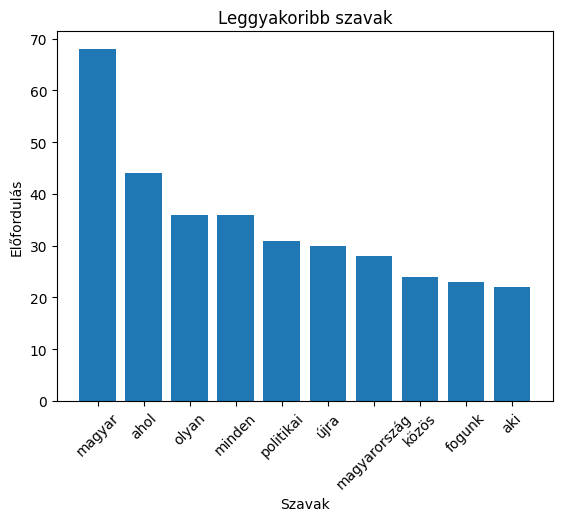

In [11]:
# ábrázoljuk diagramon
plt.bar(word_counts["word"][:10], word_counts["count"][:10])
plt.xlabel("Szavak")
plt.ylabel("Előfordulás")
plt.title("Leggyakoribb szavak")
plt.xticks(rotation=45)
plt.show()
